<a href="https://colab.research.google.com/github/noor7475/Book-Recommender-KNN/blob/main/Book_Recommender_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("books.csv", on_bad_lines='warn')

In [ ]:
df.head()

,title,authors,average_rating,language_code,num_pages,ratings_count,text_reviews_count
0,Twilight (Twilight #1),Stephenie Meyer,3.59,eng,6.218600,15.341060,11.453876
1,The Hobbit or There and Back Again,J.R.R. Tolkien,4.27,eng,5.905362,14.744084,10.400377
2,The Catcher in the Rye,J.D. Salinger,3.80,eng,5.627621,14.714490,10.680516
3,Angels & Demons (Robert Langdon #1),Dan Brown,3.89,eng,6.602588,14.698756,9.966650
4,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,eng,6.077642,14.665485,10.500289


In [ ]:
df.tail()

,title,authors,average_rating,language_code,num_pages,ratings_count,text_reviews_count
10230,Sclerotherapy and vein treatment,Robert A. Weiss/Margaret A. Weiss/Karen L. Bea...,0.00,eng,5.517453,0.0,0.0
10231,Lonely Planet Londres,Lonely Planet/Sarah Johnstone/Tom Masters,4.03,spa,6.175867,0.0,0.0
10232,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0.00,eng,5.690359,0.0,0.0
10233,Super Fast Out of Control,Louis Sachar,3.75,eng,4.859812,0.0,0.0
10234,Premières Histoires,João Guimarães Rosa,4.33,fre,5.327876,0.0,0.0


In [ ]:
df.shape

(11123, 12)

In [ ]:
df.columns

Index(['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13',
       'language_code', '  num_pages', 'ratings_count', 'text_reviews_count',
       'publication_date', 'publisher'],
      dtype='object')

# Remove spaces in columns name

In [ ]:
df.columns = df.columns.str.strip()
df.columns

Index(['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13',
       'language_code', 'num_pages', 'ratings_count', 'text_reviews_count',
       'publication_date', 'publisher'],
      dtype='object')

In [ ]:
df.describe()

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,11123.000000,11123.000000,1.112300e+04,11123.000000,1.112300e+04,11123.000000
mean,21310.856963,3.934075,9.759880e+12,336.405556,1.794285e+04,542.048099
std,13094.727252,0.350485,4.429758e+11,241.152626,1.124992e+05,2576.619589
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000
25%,10277.500000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000
50%,20287.000000,3.960000,9.780582e+12,299.000000,7.450000e+02,47.000000
75%,32104.500000,4.140000,9.780872e+12,416.000000,5.000500e+03,238.000000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


In [ ]:
df['num_pages'].value_counts().sort_index().head(6)

,count
num_pages,
0,76
1,11
2,15
3,19
4,11
5,16


# Remove books with less than 6 pages

In [ ]:
df = df[df['num_pages'] > 5]
df.shape

(10975, 12)

In [ ]:
df.describe()

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,10975.000000,10975.000000,1.097500e+04,10975.000000,1.097500e+04,10975.000000
mean,21308.088018,3.934079,9.759596e+12,340.921822,1.818035e+04,549.098314
std,13107.331732,0.348476,4.459461e+11,239.595040,1.132364e+05,2593.209491
min,1.000000,0.000000,8.987060e+09,6.000000,0.000000e+00,0.000000
25%,10246.500000,3.770000,9.780345e+12,199.000000,1.110000e+02,9.000000
50%,20250.000000,3.960000,9.780571e+12,304.000000,7.770000e+02,48.000000
75%,32109.000000,4.135000,9.780872e+12,416.000000,5.125500e+03,244.000000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


In [ ]:
df.describe(include='object')

,title,authors,language_code
count,10975,10975,10975
unique,10235,6559,27
top,The Iliad,P.G. Wodehouse,eng
freq,9,40,8789


# Drop books with duplicated titles

In [ ]:
# Keep the one with the most ratings_count
df = df.sort_values('ratings_count', ascending=False).drop_duplicates('title').reset_index(drop=True)

df.describe(include='object')

,title,authors,isbn,language_code,publication_date,publisher
count,10235,10235,10235,10235,10235,10235
unique,10235,6228,10235,26,3493,2183
top,Premières Histoires,Rumiko Takahashi,2864240157,eng,10/1/2005,Vintage
freq,1,39,1,8218,53,306


# No Missing Values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  object 
 2   authors             11123 non-null  object 
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  object 
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  object 
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  object 
 11  publisher           11123 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


In [ ]:
for i in df.columns:
  print(df[i].value_counts())
  print()

bookID
45641    1
1        1
2        1
45585    1
45583    1
        ..
12       1
10       1
9        1
8        1
5        1
Name: count, Length: 11123, dtype: int64

title
The Brothers Karamazov                                  9
The Iliad                                               9
Gulliver's Travels                                      8
The Odyssey                                             8
'Salem's Lot                                            8
                                                       ..
The Noonday Demon: An Atlas of Depression               1
The Noonday Demon: An Anatomy of Depression             1
My Secret: A PostSecret Book                            1
The Secret Lives of Men and Women: A PostSecret Book    1
Il genio dei numeri                                     1
Name: count, Length: 10348, dtype: int64

authors
Stephen King                                    40
P.G. Wodehouse                                  40
Rumiko Takahashi                  

# Drop High Cardinality and Irrelevant Columns

In [ ]:
df.drop(['bookID', 'isbn', 'isbn13', 'publication_date', 'publisher'], axis=1, inplace=True)

# Identifying unexpected dtypes in object columns (garbage values)

In [ ]:
df['language_code'].apply(type).value_counts()

,count
language_code,
<class 'str'>,11123


In [ ]:
df['authors'].apply(type).value_counts()

,count
authors,
<class 'str'>,11123


# Identifying object columns values with spaces

In [ ]:
df['authors'].str.startswith(' ').sum()
df['authors'].str.endswith(' ').sum()

np.int64(0)

In [ ]:
df['language_code'].str.startswith(' ').sum()
df['language_code'].str.endswith(' ').sum()

np.int64(0)

# Standardizing Languages Codes

In [ ]:
df['language_code'] = df['language_code'].replace({
    'en-US': 'eng',
    'en-GB': 'eng',
    'en-CA': 'eng'
})

# No duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

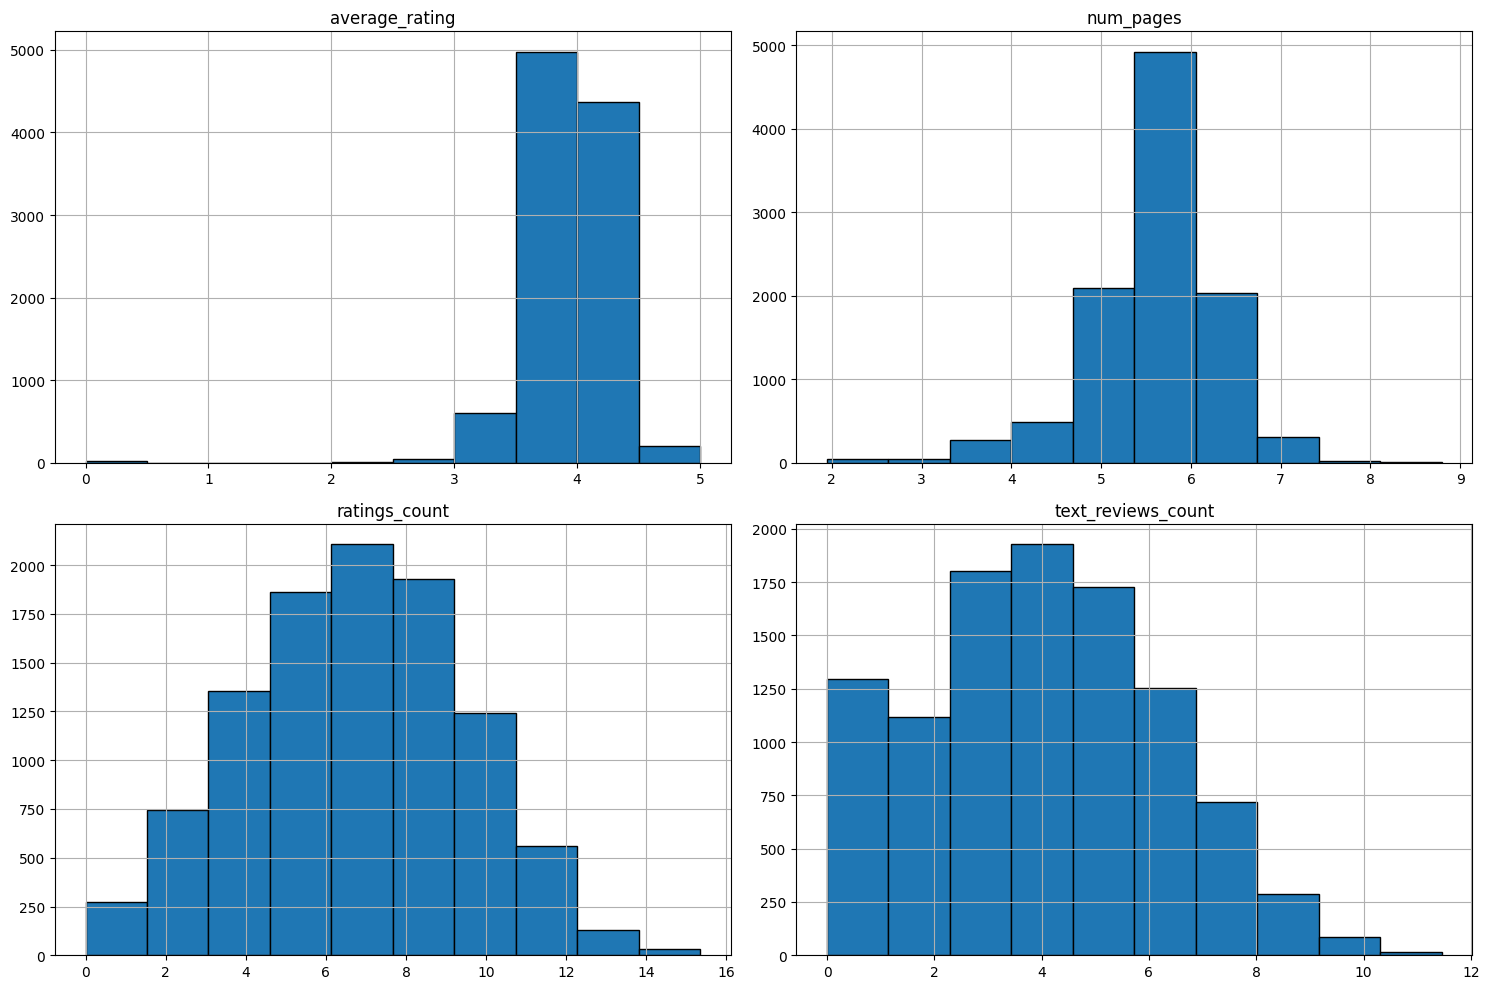

In [ ]:
import matplotlib.pyplot as plt

df.select_dtypes(include='number').hist(figsize=(15,10), edgecolor='black')
plt.tight_layout()
plt.show()

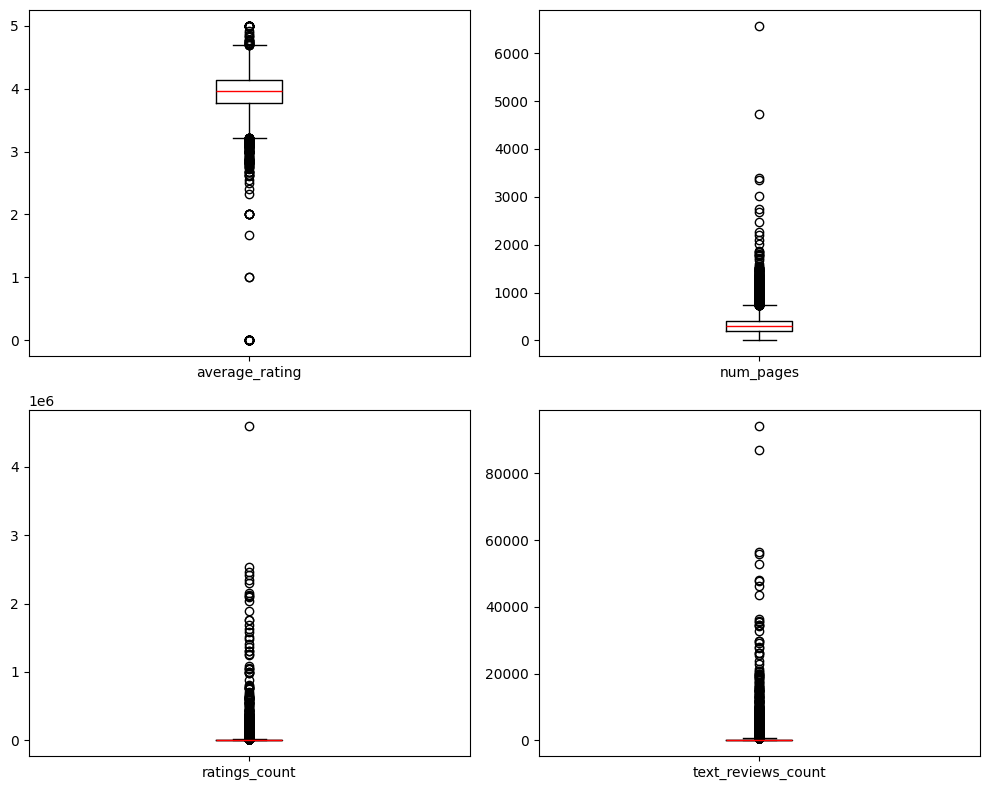

In [ ]:
df.select_dtypes(include='number').plot(kind='box', subplots=True, figsize=(10,8), layout=(-1,2), sharex=False, sharey=False, color=dict(boxes='black', whiskers='black',medians='red', caps='black'))
plt.tight_layout()
plt.show()

In [ ]:
df[df['average_rating'] < 1]

,title,authors,average_rating,language_code,num_pages,ratings_count,text_reviews_count
10163,Classroom Interactions as Cross-Cultural Encou...,Jasmine C.M. Luk/Angel M.Y. Lin,0.0,eng,241,0,0
10164,Your Child and Jesus: A Family Activity Book,Rick Osborne/Kevin Miller,0.0,eng,112,0,0
10165,"Laguna I Love You: The Best of ""Our Town""",John Weld/Phil Interlandi,0.0,eng,285,0,0
10172,Anthony Thwaite: In Conversation With Peter Da...,Peter Dale/Ian Hamilton/Anthony Thwaite,0.0,eng,96,0,0
10176,Insights: Talks On The Nature Of Existence,Frederick P. Lenz,0.0,eng,304,0,0
10177,How To Meditate: An Anthology Of Talks On Medi...,Frederick P. Lenz,0.0,eng,228,0,0
10182,Canopy: A Work for Voice and Light in Harvard ...,David Ward/Parveen Adams/Seamus Heaney/Ivan ...,0.0,eng,63,0,0
10184,The Berlin Phenomenology,Georg Wilhelm Friedrich Hegel/Michael John Petry,0.0,eng,210,0,0
10187,Venac sonetnih venaca; Puževa srma,Dobrica Erić,0.0,srp,222,0,0
10188,Mythographi Graeci 1: Apollodori Bibliotheca ...,Apollodorus/Richard Wagner,0.0,grc,335,0,0


In [ ]:
df[df['average_rating'] == 5]

,title,authors,average_rating,language_code,num_pages,ratings_count,text_reviews_count
9889,The Diamond Color Meditation: Color Pathway to...,John Diamond,5.0,eng,74,5,3
9900,Bulgakov's the Master and Margarita: The Text ...,Elena N. Mahlow,5.0,eng,202,4,0
9924,Literature Circle Guide: Bridge to Terabithia:...,Tara MacCarthy,5.0,eng,32,4,1
10055,Tyrannosaurus Wrecks (Stanley #1),Laura Driscoll/Alisa Klayman-Grodsky/Eric ...,5.0,eng,24,2,1
10061,Middlesex Borough (Images of America: New Jersey),Middlesex Borough Heritage Committee,5.0,eng,128,2,0
10067,Zone of the Enders: The 2nd Runner Official St...,Tim Bogenn,5.0,eng,128,2,0
10083,Winchester Shotguns,Dennis Adler/R.L. Wilson,5.0,eng,372,2,0
10086,The New Big Book of America,Todd Davis/Marc Frey,5.0,eng,56,2,1
10092,His Princess Devotional: A Royal Encounter Wit...,Sheri Rose Shepherd,5.0,eng,240,2,0
10101,Willem de Kooning: Late Paintings,Julie Sylvester/David Sylvester,5.0,eng,83,1,0


In [ ]:
# Remove 5 average_rating books with no ratings_count
df = df[~((df['average_rating'] == 5) & (df['ratings_count'] == 0))]

In [ ]:
df[(df['average_rating'] == 5) & (df['ratings_count'] == 0)].shape[0]

0

# Handling outliers

In [ ]:
import numpy as np

df['num_pages'] = np.log1p(df['num_pages'])
df['ratings_count'] = np.log1p(df['ratings_count'])
df['text_reviews_count'] = np.log1p(df['text_reviews_count'])

In [ ]:
df.describe()

,average_rating,num_pages,ratings_count,text_reviews_count
count,10232.000000,10232.000000,10232.000000,10232.000000
mean,3.932860,5.612612,6.727816,4.008072
std,0.354261,0.717051,2.724411,2.234140
min,0.000000,1.945910,0.000000,0.000000
25%,3.770000,5.298317,4.768557,2.397895
50%,3.960000,5.710427,6.795706,3.970292
75%,4.140000,6.028279,8.676289,5.590987
max,5.000000,8.791334,15.341060,11.453876


# Encoding

In [ ]:
!pip install category-encoders

In [ ]:
df.select_dtypes(include='object').columns

Index(['title', 'authors', 'language_code'], dtype='object')

In [ ]:
import category_encoders as ce

df_ohe = pd.get_dummies(df, columns=['language_code'], drop_first=True)

encoder = ce.BinaryEncoder(cols=['authors'])
df_encoded = encoder.fit_transform(df_ohe)

df_encoded.columns

Index(['title', 'authors_0', 'authors_1', 'authors_2', 'authors_3',
       'authors_4', 'authors_5', 'authors_6', 'authors_7', 'authors_8',
       'authors_9', 'authors_10', 'authors_11', 'authors_12', 'average_rating',
       'num_pages', 'ratings_count', 'text_reviews_count', 'language_code_eng',
       'language_code_enm', 'language_code_fre', 'language_code_ger',
       'language_code_gla', 'language_code_glg', 'language_code_grc',
       'language_code_ita', 'language_code_jpn', 'language_code_lat',
       'language_code_msa', 'language_code_mul', 'language_code_nl',
       'language_code_nor', 'language_code_por', 'language_code_rus',
       'language_code_spa', 'language_code_srp', 'language_code_swe',
       'language_code_tur', 'language_code_wel', 'language_code_zho'],
      dtype='object')

# Feature Selection

In [ ]:
X = df_encoded.drop('title', axis=1)

# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Training using Cosine similarity (focuses on feature patterns)

In [ ]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=4, algorithm='brute', metric='cosine')
knn.fit(X)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=4)

# Recommend the top 3 neighbors

In [ ]:
def recommend_books(book_title):

    book_title = book_title.lower().strip()

    if book_title not in df['title'].str.lower().values:
        return "Book not found."

    index = df[df['title'].str.lower() == book_title].index[0]

    distances, indices = knn.kneighbors([X[index]])

    similar_books = df.iloc[indices[0][1:]].copy()
    similar_books['distance'] = distances[0][1:]
    similar_books['similarity_score'] = (1 - distances[0][1:]).round(3)
    similar_books = similar_books.sort_values(by='similarity_score', ascending=False)

    return similar_books

In [ ]:
recommend_books("Expelled from Eden: A William T. Vollmann Reader")

,title,authors,average_rating,language_code,num_pages,ratings_count,text_reviews_count,distance,similarity_score
7228,Baseball: a Literary Anthology,Nicholas Dawidoff/Ernest Lawrence Thayer/Jacqu...,4.24,eng,6.598509,5.209486,2.708050,0.136052,0.864
8149,Marcel Proust: On Art and Literature 1896-1919,Marcel Proust/Sylvia Townsend Warner,4.06,eng,6.033086,4.304065,1.791759,0.137306,0.863
7779,A Sentimental Education,Gustave Flaubert/Douglas Parmée,3.83,eng,6.142037,4.663439,2.079442,0.144236,0.856


In [ ]:
book_title = df.iloc[0]['title']

recommend_books(book_title)

,title,authors,average_rating,language_code,num_pages,ratings_count,text_reviews_count,distance,similarity_score
2,The Catcher in the Rye,J.D. Salinger,3.80,eng,5.627621,14.714490,10.680516,0.080055,0.920
21,Memoirs of a Geisha,Arthur Golden,4.11,eng,6.075346,14.078708,9.867705,0.107720,0.892
158,Bel Canto,Ann Patchett,3.93,eng,5.866468,12.293149,9.473704,0.107968,0.892


In [ ]:
book_title = df.iloc[4]['title']

recommend_books(book_title)

,title,authors,average_rating,language_code,num_pages,ratings_count,text_reviews_count,distance,similarity_score
5,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling/Mary GrandPré,4.42,eng,5.834811,14.645792,10.454293,0.004014,0.996
9,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,eng,6.481577,14.555394,10.225281,0.005268,0.995
6,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,eng,6.769642,14.582451,10.282677,0.015230,0.985


# Heatmap of Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df['title'],
    columns=df['title']
)

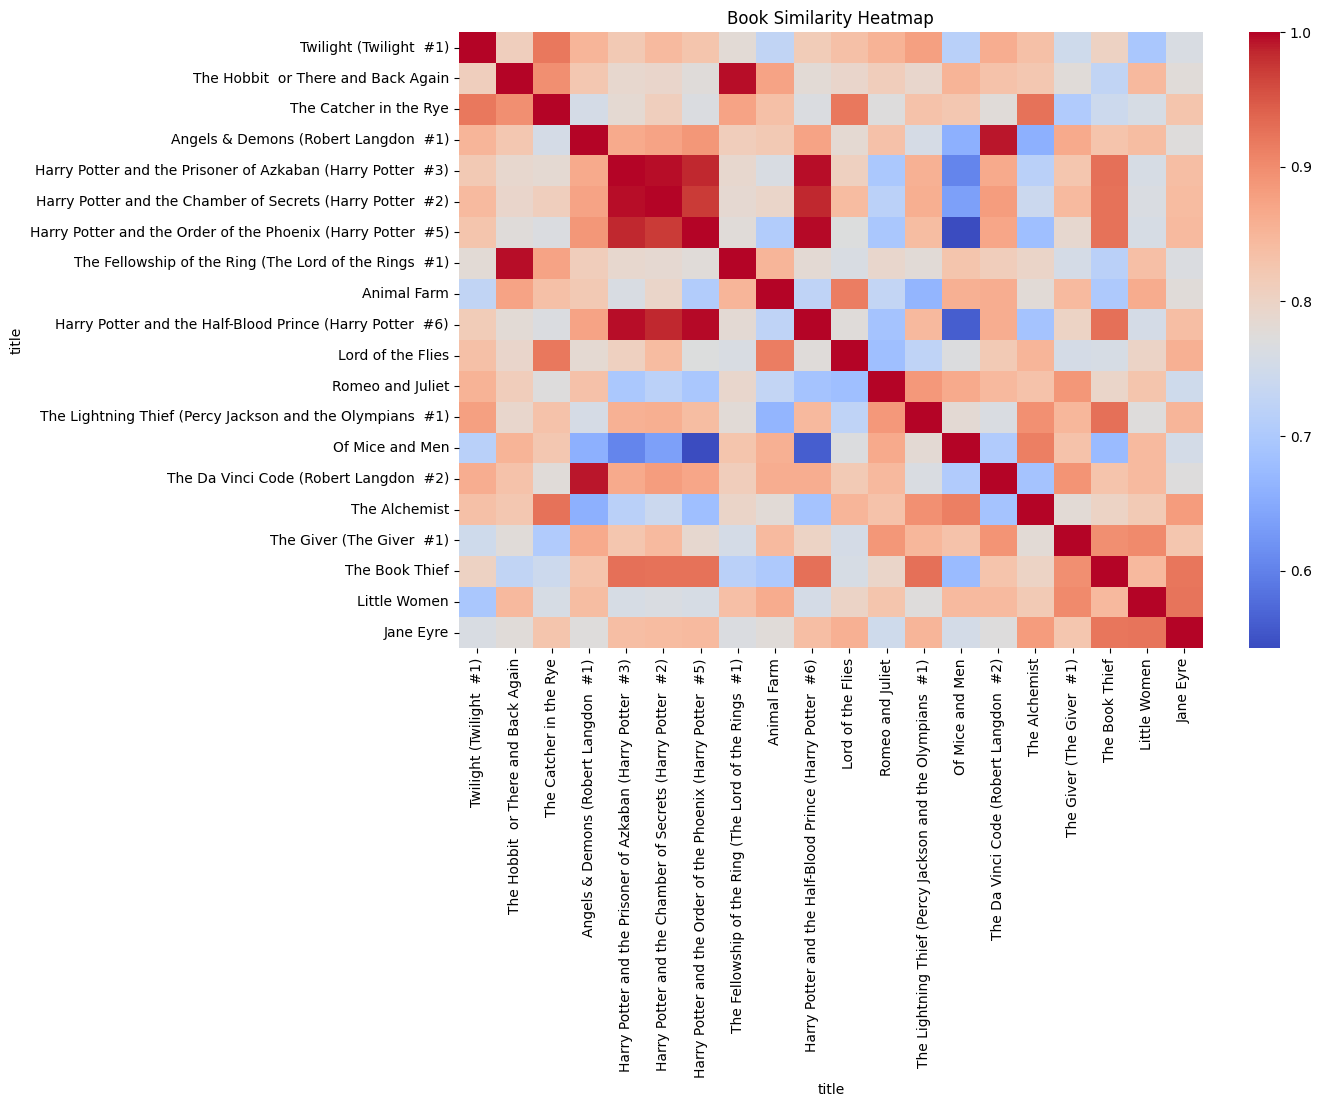

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    similarity_df.iloc[:20, :20],
    cmap='coolwarm'
)

plt.title("Book Similarity Heatmap")
plt.show()